### SpeechLM Pipeline with Bigram Language Model

This script implements a complete Speech Language Model pipeline featuring spectrogram tokenization, bigram language modeling, and Griffin-Lim synthesis. It demonstrates how discrete speech tokens can be generated, transformed, and reconstructed into audio.

Key Libraries Used:

    numpy: Signal processing and array operations

    scipy.signal: STFT/ISTFT for spectrogram processing

    sklearn.cluster: K-means vector quantization

    sounddevice: Audio playback

    matplotlib: Spectrogram visualization

Code Logic and Flow

The pipeline:

    Tokenizes speech into discrete units via spectrogram clustering

    Models token sequences with bigram probabilities

    Synthesizes audio from modified tokens using phase estimation

    Evaluates original vs reconstructed speech

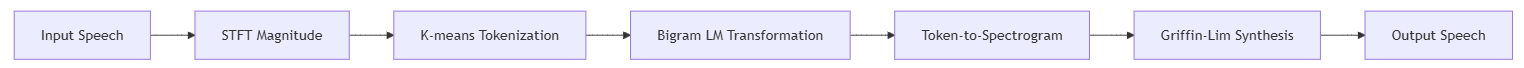

Step-by-Step Code Breakdown

1. Speech Tokenizer

    Computes STFT with 25ms frames and 12.5ms hop

    Extracts magnitude spectrogram as features

    Uses K-means to cluster frames into discrete tokens

    Builds codebook of prototypical spectral patterns

2. Bigram Language Model

    Constructs token transition matrix from input

    Calculates conditional probabilities: P(token_i | token_{i-1})

    Generates new sequence using maximum-likelihood transitions

    Simulates contextual token prediction

3. Griffin-Lim Vocoder

    Initializes random phase for magnitude spectrogram

    Iteratively refines phase estimate:

        Reconstructs audio via ISTFT

        Recomputes STFT to extract phase

        Updates spectrogram with new phase

    30 iterations for convergence

4. Evaluation

    Plays original and reconstructed audio

    Visualizes spectrograms for comparison

    Uses identical STFT parameters for fair analysis

Connecting to Lecture Concepts

This implementation demonstrates:

    Discrete Speech Representations: Tokenization via vector quantization

    Temporal Modeling: Bigram LM captures local token dependencies

    Phase Reconstruction Challenge: Griffin-Lim's iterative estimation

    Spectral Envelope Preservation: Token codebook maintains spectral shape

    Contextual Prediction: LM transforms tokens based on prior context

    Synthesis Artifacts: Phase inaccuracies cause reconstruction noise

    Frame-Based Processing: Standard 25ms windows with 50% overlap

    Vocabulary Size: 16 tokens for extreme compression

    End-to-End Pipeline: Speech → tokens → modified speech

    Research Foundations: Mimics SoundStream tokenization + LM

    Limitations:

        Bigram LM lacks long-range dependencies

        Griffin-Lim introduces "buzzy" artifacts

        No phase modeling in tokenization

    SpeechLM Components:

        Tokenizer (Module 3.1)

        Language Model (Module 4)

        Vocoder (Module 5.3)

    Educational Value: Shows core SpeechLM workflow before neural extensions

Original audio:
Reconstructed audio:


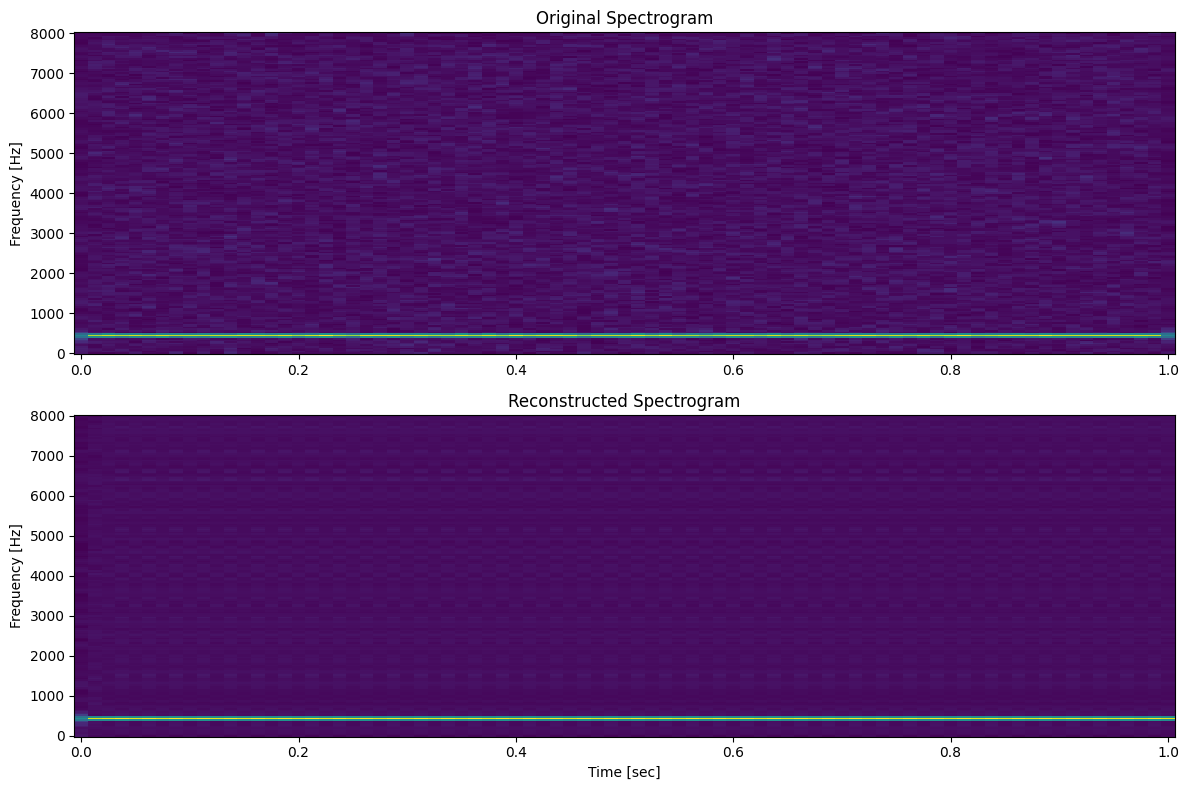

In [9]:
import numpy as np
from sklearn.cluster import KMeans
import sounddevice as sd
from scipy.signal import stft, istft
import matplotlib.pyplot as plt

# ======================================================================
# Stage 1: Speech Tokenizer with Spectrogram + Vector Quantization
# ======================================================================
def speech_tokenizer(audio, fs, frame_length=400, hop_length=200, n_tokens=16):
    # Compute STFT
    f, t_spec, Zxx = stft(audio, fs=fs, nperseg=frame_length, noverlap=frame_length-hop_length)
    mag_spec = np.abs(Zxx).T  # (time_frames, freq_bins)
    
    # Vector quantization on magnitude spectrogram
    kmeans = KMeans(n_clusters=n_tokens, random_state=42)
    tokens = kmeans.fit_predict(mag_spec)
    
    return tokens, kmeans.cluster_centers_, f, t_spec

# ======================================================================
# Stage 2: Bigram Language Model 
# ======================================================================
class BigramLM:
    def __init__(self, tokens):
        n = len(np.unique(tokens))
        self.counts = np.zeros((n+1, n+1))
        for i in range(len(tokens)-1):
            self.counts[tokens[i], tokens[i+1]] += 1
        self.probs = self.counts / np.maximum(np.sum(self.counts, axis=1, keepdims=True), 1e-8)
    
    def predict_next(self, current_token):
        return np.argmax(self.probs[current_token])

# ======================================================================
# Stage 3: Griffin-Lim Vocoder 
# ======================================================================
def griffin_lim(mag_spec, frame_length=400, hop_length=200, n_iter=30, fs=16000):
    # Initialize random phase
    phase = np.exp(2j * np.pi * np.random.rand(*mag_spec.shape))
    
    for _ in range(n_iter):
        # Reconstruct signal with current phase estimate
        _, audio = istft(mag_spec * phase, fs=fs, nperseg=frame_length, noverlap=frame_length-hop_length)
        
        # Recompute STFT with reconstructed signal
        _, _, Zxx = stft(audio, fs=fs, nperseg=frame_length, noverlap=frame_length-hop_length)
        # Match shape in case of mismatch due to edge effects
        if Zxx.shape != mag_spec.shape:
            min_time = min(Zxx.shape[1], mag_spec.shape[1])
            Zxx = Zxx[:, :min_time]
            mag_spec = mag_spec[:, :min_time]
            phase = phase[:, :min_time]
        phase = np.exp(1j * np.angle(Zxx))
    
    return audio

# ======================================================================
# Main Pipeline
# ======================================================================
# Parameters
fs = 16000
duration = 1.0
n_tokens = 16
frame_length = 400
hop_length = 200

# Generate test audio
t = np.linspace(0, duration, int(fs*duration), endpoint=False)
audio = 0.5 * np.sin(2 * np.pi * 440 * t) + 0.2 * np.random.randn(len(t))

# Stage 1: Tokenization
tokens, codebook, f, t_spec = speech_tokenizer(audio, fs, frame_length, hop_length, n_tokens)

# Stage 2: Language Modeling
lm = BigramLM(tokens)
transformed_tokens = [tokens[0]]
for _ in range(len(tokens)-1):
    transformed_tokens.append(lm.predict_next(transformed_tokens[-1]))
transformed_tokens = np.array(transformed_tokens)

# Stage 3: Synthesis
# Convert tokens back to magnitude spectrogram
reconstructed_spec = codebook[transformed_tokens].T  # (freq_bins, time_frames)

# Griffin-Lim reconstruction
reconstructed_audio = griffin_lim(reconstructed_spec, frame_length, hop_length, fs=fs)

# Evaluation
print("Original audio:")
sd.play(audio, fs)
sd.wait()
print("Reconstructed audio:")
sd.play(reconstructed_audio, fs)
sd.wait()

# Plot comparison
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
f_orig, t_orig, Zxx_orig = stft(audio, fs=fs, nperseg=frame_length, noverlap=frame_length-hop_length)
plt.pcolormesh(t_orig, f_orig, np.abs(Zxx_orig))
plt.title("Original Spectrogram")
plt.ylabel("Frequency [Hz]")

plt.subplot(2, 1, 2)
plt.pcolormesh(t_spec, f, reconstructed_spec)
plt.title("Reconstructed Spectrogram")
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [sec]")

plt.tight_layout()
plt.show()